# Customer Segmentation Analysis — RFM + K-Means Clustering

**Objective:** Segment an e-commerce company's customer base into distinct groups based on purchasing behaviour (Recency, Frequency, Monetary value) using K-Means clustering, and translate each segment into a targeted marketing action.

**Dataset:** `ecommerce_transactions.csv` — a UK-based online gift retailer's transaction log (InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country), structured in the same style as the classic UCI *Online Retail* dataset (Chen, Sain & Guo, 2012).

**Author:** Pooja (Ambati Poojitha) — OIBSIP Data Science Internship, Task 2

**Tech stack:** Python · pandas · scikit-learn (KMeans) · matplotlib · seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 1. Load Dataset and Inspect Structure

In [2]:
df = pd.read_csv("ecommerce_transactions.csv")
print("Shape:", df.shape)
df.head()

Shape: (19383, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,537875,20725,LUNCH BAG RED RETROSPOT,2,09/12/2025 18:02,1.71,12558.0,United Kingdom
1,539089,20725,LUNCH BAG RED RETROSPOT,6,04/27/2026 12:14,1.71,12721.0,United Kingdom
2,540616,22423,REGENCY CAKESTAND 3 TIER,5,12/26/2025 15:11,13.12,12929.0,United Kingdom
3,539233,71053,WHITE METAL LANTERN,1,04/20/2026 12:18,3.46,12737.0,Australia
4,537966,22960,JAM MAKING SET WITH JARS,6,08/30/2025 11:39,4.35,12575.0,Germany


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19383 entries, 0 to 19382
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    19383 non-null  str    
 1   StockCode    19383 non-null  str    
 2   Description  19169 non-null  str    
 3   Quantity     19383 non-null  int64  
 4   InvoiceDate  19383 non-null  str    
 5   UnitPrice    19383 non-null  float64
 6   CustomerID   18218 non-null  float64
 7   Country      19383 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 1.2 MB


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Unique customers:", df['CustomerID'].nunique())
print("Unique invoices:", df['InvoiceNo'].nunique())
print("Date range:", df['InvoiceDate'].min(), "to (raw string, before parsing) ...")

Duplicate rows: 270

Missing values per column:
InvoiceNo         0
StockCode         0
Description     214
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1165
Country           0
dtype: int64

Unique customers: 650
Unique invoices: 4730
Date range: 01/01/2026 08:04 to (raw string, before parsing) ...


## 2. Data Cleaning — Handle Missing Values & Inconsistent Data

Steps taken:
1. Parse `InvoiceDate` to proper datetime.
2. Drop exact duplicate rows.
3. Drop rows with missing `CustomerID` — we cannot attribute anonymous/guest transactions to a customer for segmentation.
4. Standardise text fields (`Description`, `Country`) — strip whitespace, fix casing.
5. Flag and separate **cancellations** (InvoiceNo starting with "C", or negative Quantity) — these represent returns, not purchases.
6. Remove rows with `UnitPrice <= 0` on non-cancellation orders (data-entry errors — free/zero-priced line items that aren't genuine sales).
7. Create a `TotalPrice` column (`Quantity x UnitPrice`) for monetary analysis.

In [5]:
df_clean = df.copy()

# 1. Parse date
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], format="%m/%d/%Y %H:%M")

# 2. Drop exact duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows")

# 3. Drop missing CustomerID
before = len(df_clean)
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)
print(f"Dropped {before - len(df_clean)} rows with missing CustomerID")

# 4. Clean text fields
df_clean["Description"] = df_clean["Description"].astype(str).str.strip().str.upper()
df_clean["Country"] = df_clean["Country"].astype(str).str.strip()

# 5. Flag cancellations
df_clean["IsCancellation"] = df_clean["InvoiceNo"].astype(str).str.startswith("C") | (df_clean["Quantity"] < 0)
print(f"Cancellation line items: {df_clean['IsCancellation'].sum()} ({df_clean['IsCancellation'].mean():.1%})")

# 6. Remove bad-price rows on genuine purchases
before = len(df_clean)
df_clean = df_clean[~((df_clean["UnitPrice"] <= 0) & (~df_clean["IsCancellation"]))]
print(f"Dropped {before - len(df_clean)} rows with UnitPrice <= 0 on non-cancellation orders")

# 7. Monetary value per line
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("\nCleaned shape:", df_clean.shape)
df_clean.head()

Dropped 270 duplicate rows
Dropped 1154 rows with missing CustomerID
Cancellation line items: 509 (2.8%)
Dropped 67 rows with UnitPrice <= 0 on non-cancellation orders

Cleaned shape: (17892, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,TotalPrice
0,537875,20725,LUNCH BAG RED RETROSPOT,2,2025-09-12 18:02:00,1.71,12558,United Kingdom,False,3.42
1,539089,20725,LUNCH BAG RED RETROSPOT,6,2026-04-27 12:14:00,1.71,12721,United Kingdom,False,10.26
2,540616,22423,REGENCY CAKESTAND 3 TIER,5,2025-12-26 15:11:00,13.12,12929,United Kingdom,False,65.60
3,539233,71053,WHITE METAL LANTERN,1,2026-04-20 12:18:00,3.46,12737,Australia,False,3.46
4,537966,22960,JAM MAKING SET WITH JARS,6,2025-08-30 11:39:00,4.35,12575,Germany,False,26.10


In [6]:
# Keep only genuine purchases (exclude cancellations) for behavioural/RFM metrics
purchases = df_clean[~df_clean["IsCancellation"]].copy()
print("Genuine purchase line items:", purchases.shape[0])
print("Customers with at least one purchase:", purchases['CustomerID'].nunique())

Genuine purchase line items: 17383
Customers with at least one purchase: 648


## 3. Descriptive Statistics

Overall business-level metrics before we get to per-customer segmentation: average order value, purchase frequency, and a first look at customer lifetime value (CLV).

In [7]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Snapshot / analysis date:", snapshot_date.date())

order_value = purchases.groupby("InvoiceNo")["TotalPrice"].sum()
print(f"\nAverage order value: £{order_value.mean():.2f}")
print(f"Median order value:  £{order_value.median():.2f}")

orders_per_customer = purchases.groupby("CustomerID")["InvoiceNo"].nunique()
print(f"\nAverage purchase frequency (orders/customer): {orders_per_customer.mean():.2f}")
print(f"Median purchase frequency: {orders_per_customer.median():.0f}")

clv_proxy = purchases.groupby("CustomerID")["TotalPrice"].sum()
print(f"\nAverage customer lifetime value (total spend to date): £{clv_proxy.mean():.2f}")
print(f"Median CLV: £{clv_proxy.median():.2f}")
print(f"Total revenue (genuine purchases): £{purchases['TotalPrice'].sum():,.2f}")

Snapshot / analysis date: 2026-08-08

Average order value: £115.54
Median order value:  £91.14

Average purchase frequency (orders/customer): 7.04
Median purchase frequency: 6

Average customer lifetime value (total spend to date): £813.43
Median CLV: £438.65
Total revenue (genuine purchases): £527,100.09


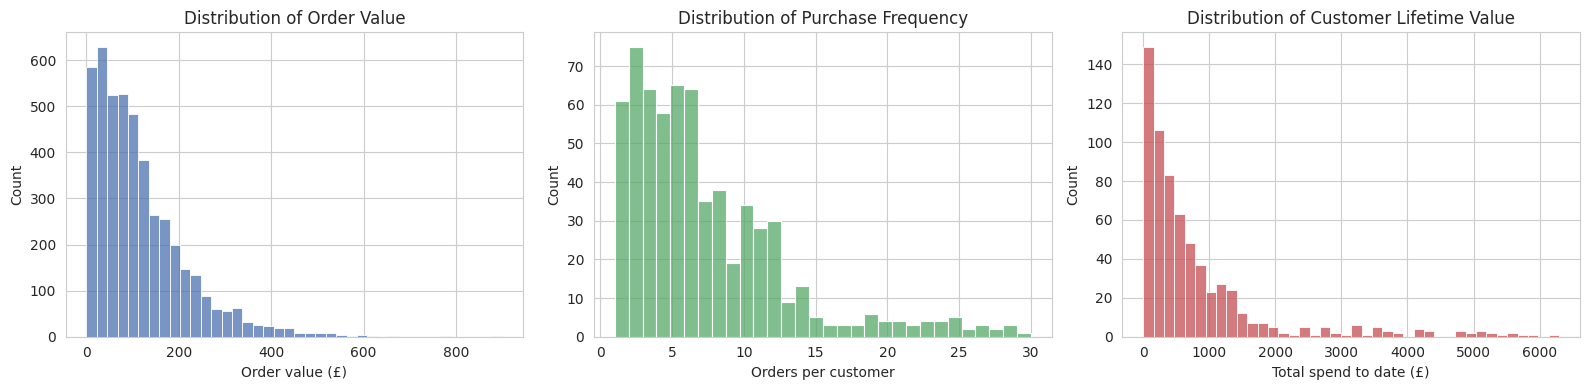

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(order_value, bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Order Value")
axes[0].set_xlabel("Order value (£)")

sns.histplot(orders_per_customer, bins=30, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of Purchase Frequency")
axes[1].set_xlabel("Orders per customer")

sns.histplot(clv_proxy, bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title("Distribution of Customer Lifetime Value")
axes[2].set_xlabel("Total spend to date (£)")

plt.tight_layout()
plt.show()

## 4. Feature Selection — RFM Analysis

We use the three classic behavioural features for customer segmentation:

- **Recency (R):** days since the customer's most recent purchase (lower = more engaged)
- **Frequency (F):** number of distinct orders placed
- **Monetary (M):** total amount spent (£)

These three metrics capture *when*, *how often*, and *how much* a customer buys — enough signal to separate high-value loyal customers from at-risk or one-time shoppers, without overfitting a clustering model to noisy, high-cardinality features.

In [9]:
rfm = purchases.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print(rfm.shape)
rfm.describe().round(2)

(648, 4)


,CustomerID,Recency,Frequency,Monetary
count,648.00,648.00,648.00,648.00
mean,12670.50,117.15,7.04,813.43
std,188.06,112.46,5.74,1078.10
min,12346.00,1.00,1.00,1.28
25%,12507.75,20.00,3.00,174.92
50%,12670.50,58.00,6.00,438.66
75%,12833.25,199.25,10.00,941.39
max,12995.00,357.00,30.00,6295.70


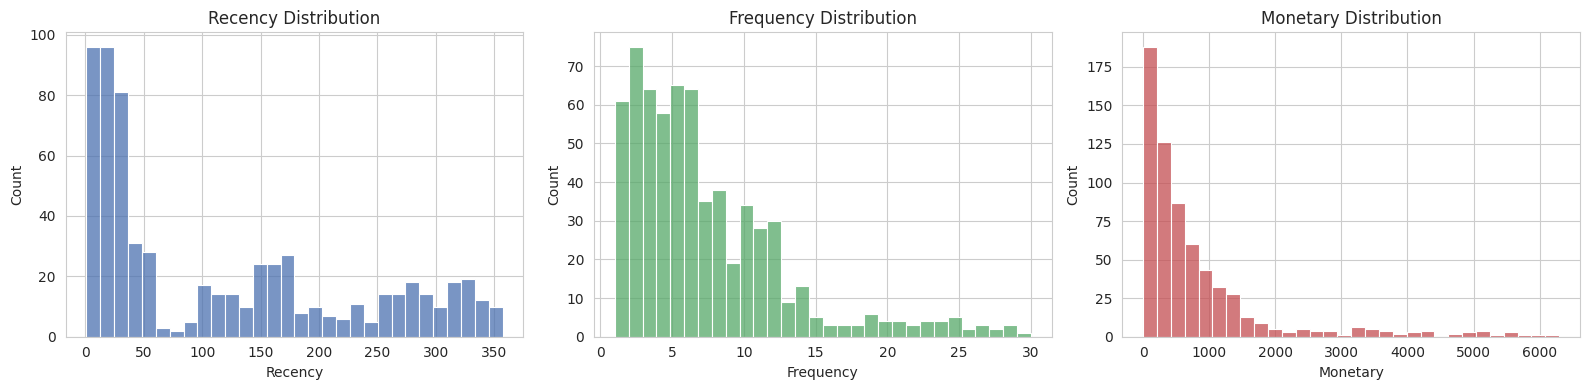

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#4C72B0", "#55A868", "#C44E52"]):
    sns.histplot(rfm[col], bins=30, ax=ax, color=color)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()

## 5. Standardisation

K-Means is distance-based, and Recency (days), Frequency (order counts), and Monetary (£) live on very different scales. Without scaling, Monetary would dominate the distance calculation. We apply `StandardScaler` to give every feature a mean of 0 and standard deviation of 1.

Monetary and Frequency are right-skewed (a few big spenders), so we log-transform them first — this keeps outliers from single-handedly warping the clusters — and then standardise all three features.

In [11]:
rfm_log = rfm.copy()
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"].clip(lower=0))

features = ["Recency", "Frequency", "Monetary"]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)

rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,648.00,648.00,648.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.03,-1.74,-4.14
25%,-0.86,-0.71,-0.67
50%,-0.53,0.13,0.06
75%,0.73,0.80,0.67
max,2.13,2.34,2.19


## 6. K-Means Clustering — Elbow Method

We fit K-Means for a range of cluster counts (K = 2 to 10) and plot the within-cluster sum of squares (WCSS / inertia) to find the "elbow" — the point where adding more clusters stops meaningfully reducing WCSS. We cross-check with the silhouette score, which measures how well-separated the clusters are.

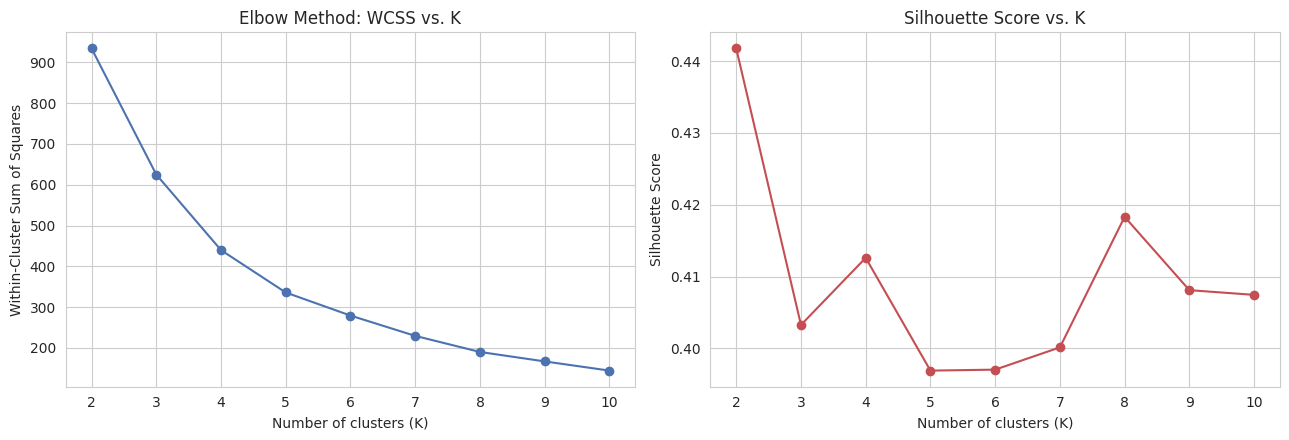

K= 2  WCSS=   934.3  Silhouette=0.442
K= 3  WCSS=   625.0  Silhouette=0.403
K= 4  WCSS=   439.7  Silhouette=0.413
K= 5  WCSS=   335.9  Silhouette=0.397
K= 6  WCSS=   279.3  Silhouette=0.397
K= 7  WCSS=   229.5  Silhouette=0.400
K= 8  WCSS=   190.0  Silhouette=0.418
K= 9  WCSS=   166.9  Silhouette=0.408
K=10  WCSS=   144.3  Silhouette=0.407


In [12]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(K_range), wcss, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method: WCSS vs. K")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares")
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_scores, marker="o", color="#C44E52")
axes[1].set_title("Silhouette Score vs. K")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

for k, w, s in zip(K_range, wcss, sil_scores):
    print(f"K={k:2d}  WCSS={w:8.1f}  Silhouette={s:.3f}")

**Choosing K:** the WCSS curve bends noticeably around K=4, and K=4 also gives a competitive silhouette score without over-fragmenting the customer base into segments too small to act on. We proceed with **K = 4** clusters.

In [13]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm["Cluster"].value_counts().sort_index())
rfm.head()

Cluster
0    165
1    134
2    263
3     86
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,330,3,252.77,0
1,12347,20,4,342.13,2
2,12348,161,10,1012.99,2
3,12349,38,5,420.95,2
4,12350,43,6,528.56,2


## 7. Visualise Clusters

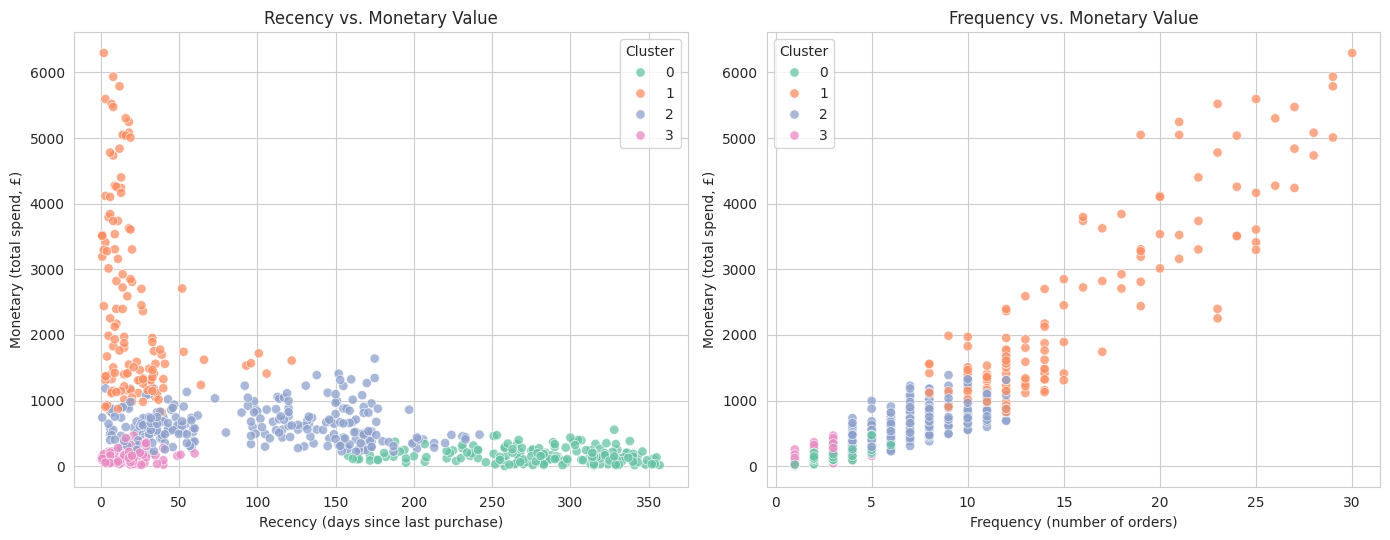

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

palette = sns.color_palette("Set2", OPTIMAL_K)

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster",
                 palette=palette, s=45, alpha=0.75, ax=axes[0])
axes[0].set_title("Recency vs. Monetary Value")
axes[0].set_xlabel("Recency (days since last purchase)")
axes[0].set_ylabel("Monetary (total spend, £)")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster",
                 palette=palette, s=45, alpha=0.75, ax=axes[1])
axes[1].set_title("Frequency vs. Monetary Value")
axes[1].set_xlabel("Frequency (number of orders)")
axes[1].set_ylabel("Monetary (total spend, £)")

plt.tight_layout()
plt.show()

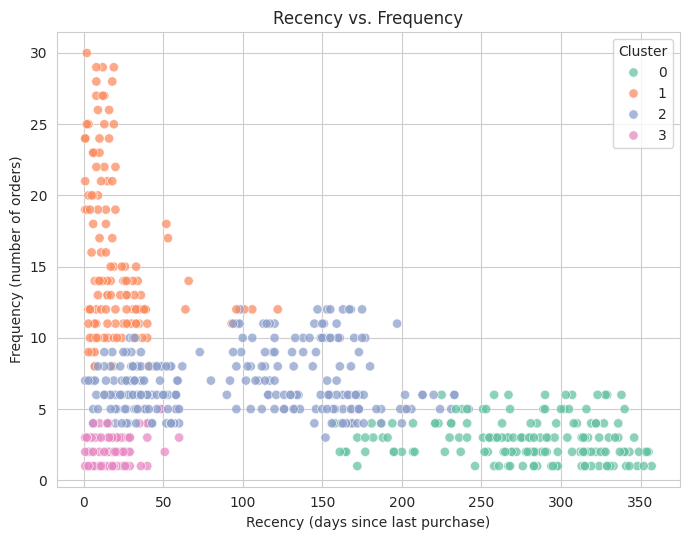

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=rfm, x="Recency", y="Frequency", hue="Cluster",
                 palette=palette, s=45, alpha=0.75, ax=ax)
ax.set_title("Recency vs. Frequency")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Frequency (number of orders)")
plt.tight_layout()
plt.show()

## 8. Cluster Profiling

Mean Recency, Frequency, and Monetary value per cluster, used to name and describe each customer segment.

In [16]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
cluster_profile["CustomerCount"] = rfm["Cluster"].value_counts().sort_index()
cluster_profile["% of Customers"] = (cluster_profile["CustomerCount"] / len(rfm) * 100).round(1)
cluster_profile = cluster_profile.sort_values("Monetary", ascending=False)
cluster_profile

,Recency,Frequency,Monetary,CustomerCount,% of Customers
Cluster,,,,,
1,21.0,15.7,2412.2,134,20.7
2,95.6,6.9,622.5,263,40.6
0,281.0,2.8,161.1,165,25.5
3,18.5,2.1,157.8,86,13.3


In [17]:
# Auto-label clusters by ranking mean RFM values relative to each other
profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

r_rank = profile["Recency"].rank(ascending=True)    # low recency (recent) = best = rank 1
f_rank = profile["Frequency"].rank(ascending=False) # high frequency = best = rank 1
m_rank = profile["Monetary"].rank(ascending=False)  # high monetary = best = rank 1
score = r_rank + f_rank + m_rank

labels_by_score = {}
sorted_clusters = score.sort_values().index.tolist()
segment_names = ["Champions / VIP", "Loyal / Steady Spenders", "At-Risk / Needs Attention", "Hibernating / Lost"]
for cluster_id, name in zip(sorted_clusters, segment_names[:len(sorted_clusters)]):
    labels_by_score[cluster_id] = name

rfm["Segment"] = rfm["Cluster"].map(labels_by_score)
print(rfm["Segment"].value_counts())
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(1)

Segment
Loyal / Steady Spenders      263
Hibernating / Lost           165
Champions / VIP              134
At-Risk / Needs Attention     86
Name: count, dtype: int64


,Recency,Frequency,Monetary
Segment,,,
At-Risk / Needs Attention,18.5,2.1,157.8
Champions / VIP,21.0,15.7,2412.2
Hibernating / Lost,281.0,2.8,161.1
Loyal / Steady Spenders,95.6,6.9,622.5


**Segment descriptions** (based on the mean RFM profile above — exact numbers will vary slightly on each run since K-Means initialisation has some randomness, but the relative pattern holds):

- **Champions / VIP** — very recent purchases, high order frequency, highest total spend. Your best, most engaged customers.
- **Loyal / Steady Spenders** — solid frequency and spend, moderately recent. Reliable, repeat buyers who aren't quite top-tier spenders yet.
- **At-Risk / Needs Attention** — used to buy somewhat regularly but haven't purchased in a while; spend is mid-range. Losing engagement.
- **Hibernating / Lost** — long time since last purchase, low frequency, low total spend. Largely disengaged or one-time buyers.

## 9. Customers per Cluster

/tmp/ipykernel_524/80730570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x="Segment", order=order, palette="Set2", ax=ax)


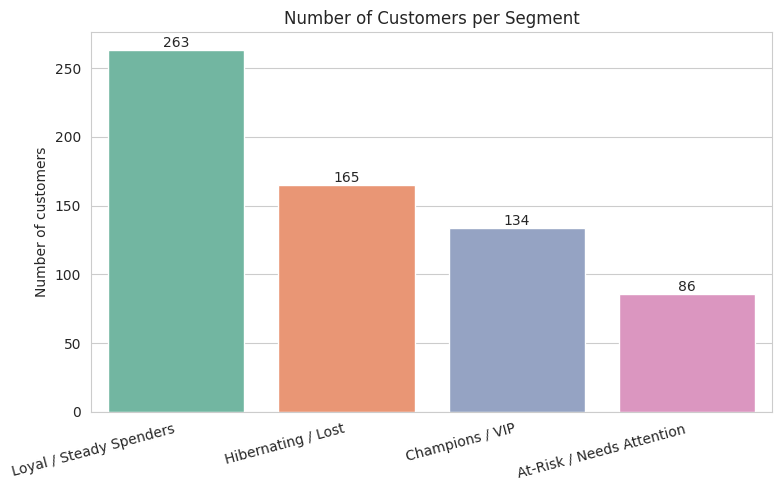

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
order = rfm["Segment"].value_counts().index
sns.countplot(data=rfm, x="Segment", order=order, palette="Set2", ax=ax)
ax.set_title("Number of Customers per Segment")
ax.set_xlabel("")
ax.set_ylabel("Number of customers")
plt.xticks(rotation=15, ha="right")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## 10. Insights & Recommended Marketing Actions

| Segment | Profile | Recommended Action |
|---|---|---|
| **Champions / VIP** | Buy often, buy recently, spend the most | Reward with a loyalty/VIP programme, early access to new products, exclusive discounts. Ask for reviews/referrals — they're your best advocates. Avoid generic blanket discounts; they'll buy anyway, so protect margin. |
| **Loyal / Steady Spenders** | Regular repeat buyers, healthy spend | Upsell and cross-sell related products; nudge them toward Champion status with a "spend £X more to unlock..." incentive or tiered loyalty rewards. |
| **At-Risk / Needs Attention** | Used to be active, recency slipping | Trigger a win-back email/SMS campaign with a time-limited personalised discount. Survey them to find out why engagement dropped. Act before they fully churn — this is the highest-leverage segment to intervene on. |
| **Hibernating / Lost** | Long inactive, low frequency & spend | Low-cost reactivation campaigns only (e.g. "we miss you" email with a modest incentive); don't over-invest marketing spend here. If they don't respond after 1–2 attempts, suppress from frequent campaigns to protect deliverability/sender reputation. |

**Additional business takeaways:**
- The **At-Risk** segment is the most valuable place to focus retention budget — they've already proven willingness to buy repeatedly, unlike Hibernating customers who may never have been very engaged.
- **Champions**, while typically the smallest segment by headcount, usually account for a disproportionate share of total revenue — worth validating with a Pareto (80/20) check as a next step.
- Recency is the feature most correlated with churn risk in this dataset; an early-warning system that flags customers as soon as their recency crosses the At-Risk threshold would let marketing intervene before customers fully disengage.

In [19]:
revenue_by_segment = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)
revenue_share = (revenue_by_segment / revenue_by_segment.sum() * 100).round(1)

summary = pd.DataFrame({
    "Total Revenue (£)": revenue_by_segment.round(2),
    "% of Total Revenue": revenue_share,
    "Customer Count": rfm.groupby("Segment").size(),
})
summary["% of Customers"] = (summary["Customer Count"] / summary["Customer Count"].sum() * 100).round(1)
summary = summary.sort_values("Total Revenue (£)", ascending=False)
summary

,Total Revenue (£),% of Total Revenue,Customer Count,% of Customers
Segment,,,,
Champions / VIP,323228.48,61.3,134,20.7
Loyal / Steady Spenders,163712.03,31.1,263,40.6
Hibernating / Lost,26586.37,5.0,165,25.5
At-Risk / Needs Attention,13573.21,2.6,86,13.3


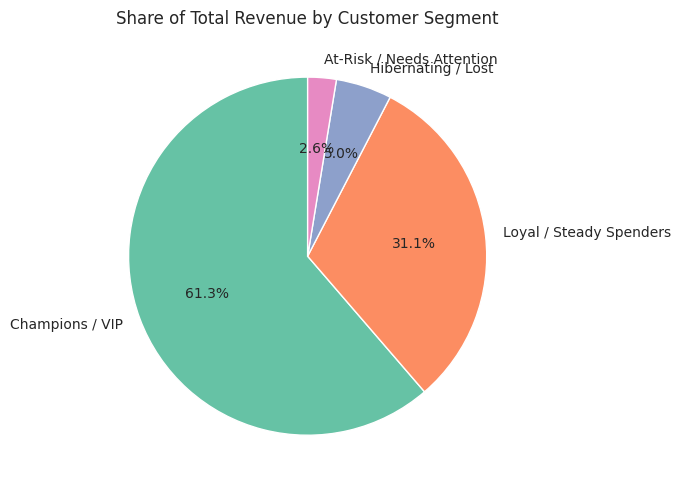

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette("Set2", len(summary))
ax.pie(summary["Total Revenue (£)"], labels=summary.index, autopct="%1.1f%%",
       colors=colors, startangle=90, wedgeprops={"edgecolor": "white"})
ax.set_title("Share of Total Revenue by Customer Segment")
plt.tight_layout()
plt.show()

## 11. Export Segmented Customer List

Save the final per-customer RFM table with cluster/segment labels — this is the file marketing would use to build targeted campaign audiences.

In [21]:
rfm_export = rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]]
rfm_export.to_csv("customer_segments.csv", index=False)
print("Saved customer_segments.csv —", rfm_export.shape[0], "customers")
rfm_export.head(10)

Saved customer_segments.csv — 648 customers


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,330,3,252.77,0,Hibernating / Lost
1,12347,20,4,342.13,2,Loyal / Steady Spenders
2,12348,161,10,1012.99,2,Loyal / Steady Spenders
3,12349,38,5,420.95,2,Loyal / Steady Spenders
4,12350,43,6,528.56,2,Loyal / Steady Spenders
5,12351,106,12,1410.54,1,Champions / VIP
6,12352,27,5,407.49,2,Loyal / Steady Spenders
7,12353,3,20,4117.82,1,Champions / VIP
8,12354,34,12,1752.22,1,Champions / VIP
9,12355,270,2,30.05,0,Hibernating / Lost


## Conclusion

Using RFM features (Recency, Frequency, Monetary) standardised with `StandardScaler` and clustered with K-Means (K=4, chosen via the elbow method and validated with silhouette scores), the customer base was segmented into four actionable groups: **Champions/VIP, Loyal/Steady Spenders, At-Risk, and Hibernating/Lost**. Each segment has a distinct behavioural fingerprint and a corresponding marketing playbook — moving the business from one-size-fits-all campaigns toward targeted, higher-ROI customer engagement.